1年先の予測を行うにあたり、直近の2021年8月〜2022年7月をテストデータとし、それ以前を学習データとする

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
import seaborn as sns
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('../data/Transport_amount_data.csv')
df['label'] = pd.to_datetime(df['label'])
df

,label,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2
0,2002-04-01,2002,4,5933686,218721,26,20
1,2002-05-01,2002,5,5474539,208283,26,20
2,2002-06-01,2002,6,5430018,218633,26,20
3,2002-07-01,2002,7,6345951,271764,26,20
4,2002-08-01,2002,8,5354671,217650,26,20
...,...,...,...,...,...,...,...
239,2022-03-01,2022,3,6118588,426615,24,14
240,2022-04-01,2022,4,5727532,387559,24,14
241,2022-05-01,2022,5,5102766,380692,24,14
242,2022-06-01,2022,6,5723215,411429,24,14


In [4]:
df = df.set_index('label')

In [5]:
df

,year,month,Transport_tonnage,number_parcels,Number_companies_1,Number_companies_2
label,,,,,,
2002-04-01,2002,4,5933686,218721,26,20
2002-05-01,2002,5,5474539,208283,26,20
2002-06-01,2002,6,5430018,218633,26,20
2002-07-01,2002,7,6345951,271764,26,20
2002-08-01,2002,8,5354671,217650,26,20
...,...,...,...,...,...,...
2022-03-01,2022,3,6118588,426615,24,14
2022-04-01,2022,4,5727532,387559,24,14
2022-05-01,2022,5,5102766,380692,24,14


In [6]:
# 前処理系
df.index = pd.to_datetime(df.index)
df['log_parcels'] = np.log(df['number_parcels'])

# 2. 外生変数（ダミー変数）の作成（論文の定義に準拠）
df['hike_dummy'] = 0
df.loc['2017-10-01':'2019-12-01', 'hike_dummy'] = 1

df['covid_main'] = 0
df.loc['2020-03-01':, 'covid_main'] = 1

df['covid_wave1'] = 0
df.loc['2020-04-01':'2020-05-01', 'covid_wave1'] = 1

df['covid_2021'] = 0
df.loc['2021-01-01':'2021-09-01', 'covid_2021'] = 1

exog_cols = ['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021']

In [7]:
# データの分割
train = df.loc[:'2021-07-01']
test = df.loc['2021-08-01':'2022-07-01']

y_train = train['log_parcels']
exog_train = train[exog_cols]

y_test = test['log_parcels']
exog_test = test[exog_cols]

In [14]:
# 4. SARIMAXモデルの構築と学習
# ※ order=(p,d,q), seasonal_order=(P,D,Q,s) は一般的なベースライン値を設定
model = SARIMAX(
    endog=y_train,
    exog=exog_train,
    order=(2, 1, 3),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
# 5. テストデータ期間の予測
pred = results.get_forecast(steps=len(test), exog=exog_test)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

In [16]:
# 6. 精度評価 (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, pred_mean))
print(f"テストデータに対するRMSE (対数スケール): {rmse:.4f}")

テストデータに対するRMSE (対数スケール): 0.0479


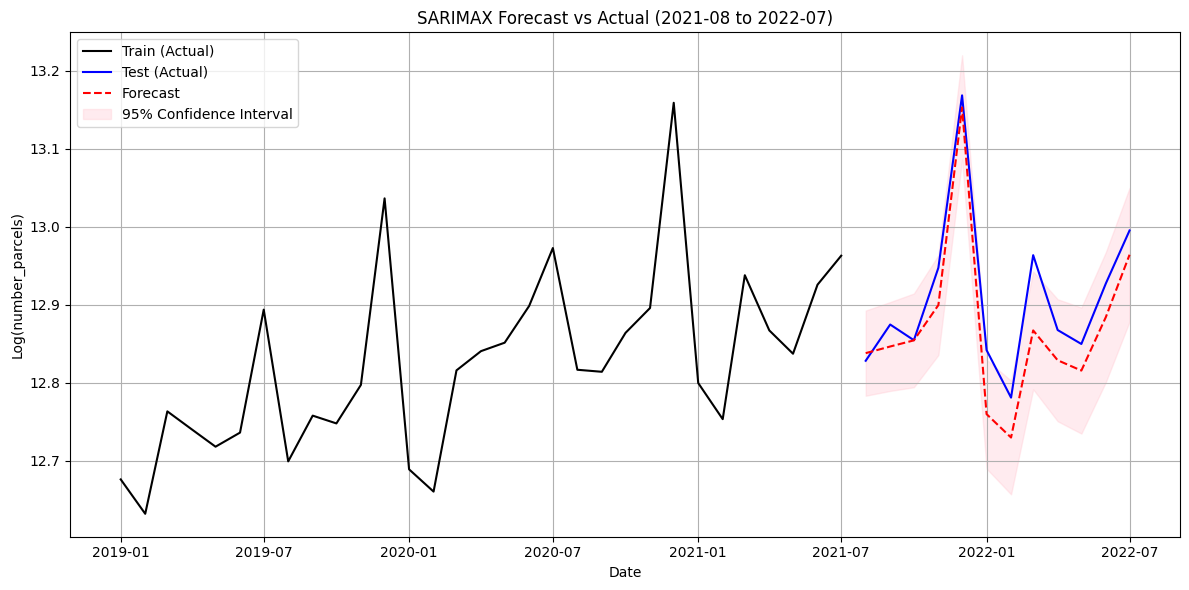

In [17]:
plt.figure(figsize=(12, 6))
plot_start = '2019-01-01'
plt.plot(train.loc[plot_start:].index, train.loc[plot_start:]['log_parcels'], label='Train (Actual)', color='black')
plt.plot(test.index, y_test, label='Test (Actual)', color='blue')
plt.plot(test.index, pred_mean, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('SARIMAX Forecast vs Actual (2021-08 to 2022-07)')
plt.ylabel('Log(number_parcels)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()